In [145]:
import torch
import numpy
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

In [115]:
dataset = datasets.EuroSAT(
    root="data",
    download=True,
    transform=ToTensor()
)

train_split = int(len(dataset) * 0.7)
validate_split = int(len(dataset)*0.2)
test_split = int(len(dataset)*0.1)
generator = torch.manual_seed(42)
training_data, validation_data, testing_data = torch.utils.data.random_split(dataset, [train_split, validate_split, test_split], generator = generator)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validate_dataloader = DataLoader(validation_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(testing_data, batch_size=64, shuffle=False)

In [116]:
class ConvNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
        #3x64x64
        nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #32x32x32
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #64x16x16
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        #128x8x8
    )
    self.classifier = nn.Sequential(
        nn.LazyLinear(256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256,10)
        # nn.ReLU(),
        # # nn.Dropout(0.5),
        # nn.Linear(512,10)
    )

  def forward(self, x):
    x = self.features(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x

In [117]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

model = ConvNet().to(device)
print(model)

Using mps device
ConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): LazyLinear(in_features=0, out_features=256, bias=True)
    (1): ReLU()
    (2):

In [146]:
def training_loop(dataloader, model, loss_fn, optimizer):
  model.train()
  size = len(dataloader.dataset)
  total_loss = 0
  total = 0
  correct = 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    total += y.size(0)
    _, predicted = torch.max(pred.data, 1)
    correct += (predicted == y).sum().item()
    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
  avg_training_loss = total_loss/len(dataloader)
  training_accuracy = (correct/total)*100 # Corrected calculation
  print(f"\nTraining Accuracy: {training_accuracy}% | Avg Training Loss: {avg_training_loss}")

y_true = []
y_pred = []
def validation_loop(dataloader, model, loss_fn, test):
  model.eval()
  size = len(dataloader.dataset)
  with torch.no_grad():
    total_loss = 0
    total = 0
    correct = 0
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      pred = model(X)
      y_pred.extend((pred.argmax(dim=1)).cpu().numpy())
      y_true.extend(y.cpu().numpy())
      total_loss += loss_fn(pred, y).item()
      total += y.size(0)
      _, predicted = torch.max(pred.data, 1)
      correct += (predicted == y).sum().item()
    avg_testing_loss = total_loss/len(dataloader)
    testing_accuracy = (correct/total)*100 # Corrected calculation
    print(f"Validation Accuracy: {testing_accuracy}% | Avg Validation Loss: {avg_testing_loss} \n")
    return avg_testing_loss, testing_accuracy

In [147]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
epochs = 30
best_val_loss = 100
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     training_loop(train_dataloader, model, loss_fn, optimizer)
#     val_loss, val_acc = validation_loop(validate_dataloader, model, loss_fn, False)
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "best_model.pth")
print("Testing \n-------------------------------")
model.load_state_dict(torch.load("best_model.pth"))
validation_loop(test_dataloader, model, loss_fn, True)
print("Done!")

Testing 
-------------------------------
Validation Accuracy: 92.85185185185185% | Avg Validation Loss: 0.266948729450273 

Done!


In [161]:
# for x in y_true:
#     print(x.item())

7
1
1
0
6
1
9
7
3
4
7
7
4
3
7
1
9
8
5
0
2
6
3
3
2
0
3
9
7
1
5
3
7
0
1
4
9
7
2
2
9
6
5
2
0
6
8
8
3
7
7
0
8
3
3
8
1
0
0
6
5
0
6
5
2
9
2
1
1
9
8
0
0
6
9
0
3
8
9
7
3
2
4
4
4
0
3
9
6
5
4
9
9
3
3
3
3
7
7
2
3
0
7
5
0
3
4
6
2
0
4
8
0
4
9
3
7
9
3
8
6
8
7
8
7
0
6
0
6
1
6
0
7
1
6
7
9
8
7
2
3
1
4
2
7
2
9
3
9
3
3
9
6
8
0
0
9
8
7
2
2
8
7
5
8
6
9
6
7
6
2
1
1
2
4
8
2
8
1
5
3
2
0
8
4
8
1
1
0
0
0
2
4
1
4
6
8
1
7
0
9
9
2
4
0
9
0
8
4
7
4
2
1
6
8
0
3
6
3
4
0
9
7
2
0
1
1
0
6
4
7
7
4
2
7
2
6
3
7
9
9
4
0
7
9
8
6
2
6
1
2
6
8
9
8
9
2
5
6
4
3
7
5
4
1
9
1
2
6
1
2
1
7
1
5
1
2
0
9
4
3
0
6
0
5
1
7
3
5
1
4
8
7
0
4
9
8
3
0
7
3
7
2
9
6
2
3
3
5
2
6
7
9
9
0
3
7
2
7
8
6
1
3
0
0
6
0
9
9
0
1
6
5
0
7
2
9
8
5
2
7
1
0
2
1
8
9
6
3
6
4
8
9
9
9
1
1
9
9
7
4
7
7
9
1
7
2
6
2
4
5
6
9
8
7
8
9
1
2
7
3
6
6
0
7
2
0
0
7
8
2
5
7
6
3
6
2
9
5
6
0
1
4
0
7
0
8
7
1
7
9
3
8
0
9
2
5
8
9
6
0
4
7
3
0
6
9
9
7
2
3
3
0
1
9
4
5
4
2
6
7
2
4
9
6
7
9
8
4
0
1
6
6
6
1
4
3
7
9
2
4
0
4
9
6
7
0
1
5
7
4
4
1
8
9
1
2
9
7
0
9
6
7
2
1
1
1
7
6
6
5
6
9
2
2
5
4
3
2
0


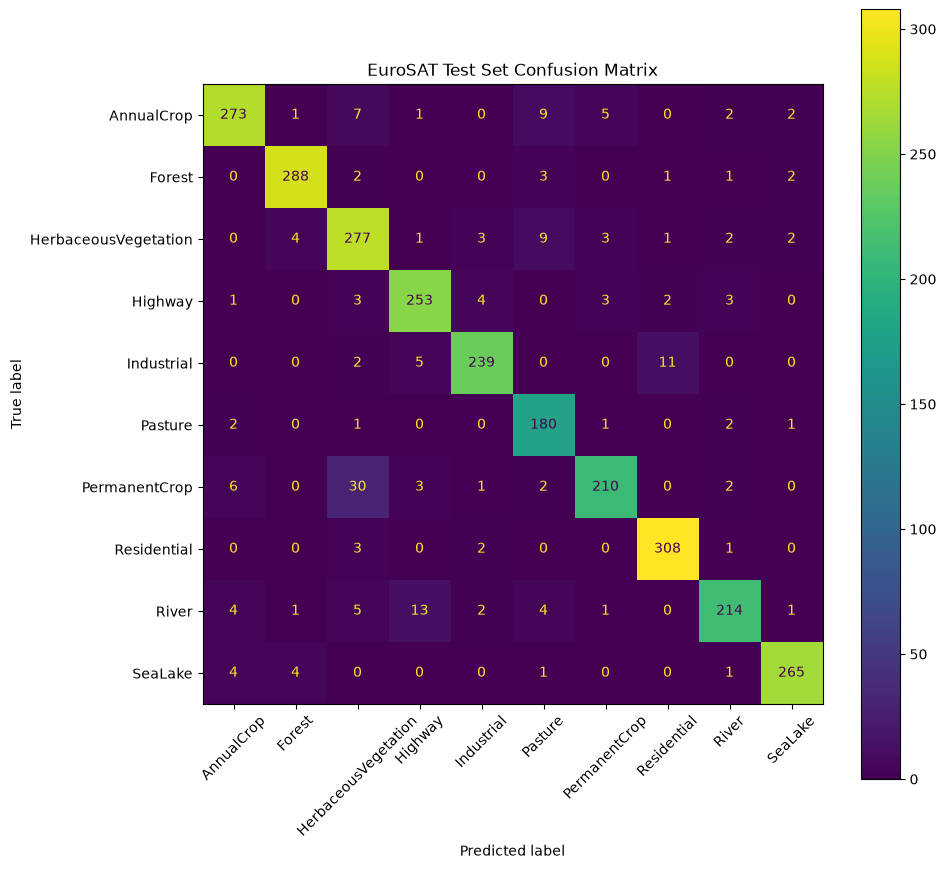

In [157]:
# Confusion Matrix

import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = dataset.classes
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("EuroSAT Test Set Confusion Matrix")
plt.show()

plt.show()

In [163]:
from sklearn.metrics import classification_report
cr = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(cr)

                      precision    recall  f1-score   support

          AnnualCrop      0.941     0.910     0.925       300
              Forest      0.966     0.970     0.968       297
HerbaceousVegetation      0.839     0.917     0.877       302
             Highway      0.917     0.941     0.928       269
          Industrial      0.952     0.930     0.941       257
             Pasture      0.865     0.963     0.911       187
       PermanentCrop      0.942     0.827     0.881       254
         Residential      0.954     0.981     0.967       314
               River      0.939     0.873     0.905       245
             SeaLake      0.971     0.964     0.967       275

            accuracy                          0.929      2700
           macro avg      0.929     0.927     0.927      2700
        weighted avg      0.930     0.929     0.928      2700



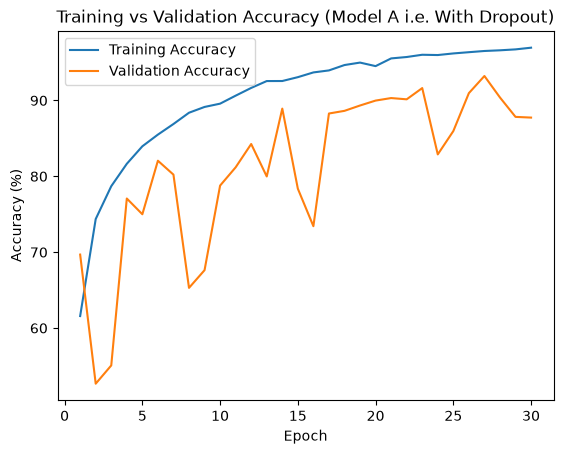

In [124]:
# With Dropout (Model A)
epochs_A = list(range(1, 31))

train_accuracy_A = [61.5820,74.3704,78.6984,81.6508,83.9577,85.4974,86.8942,88.3810,89.1429,89.5767,90.6296,91.6508,92.5556,92.5608,93.0688,93.6931,93.9577,94.6667,94.9894,94.5238,95.5397,95.7249,96.0212,95.9841,96.1958,96.3598,96.5185,96.6085,96.7302,96.9524]

val_accuracy_A = [
    69.6852,
    52.6667,
    55.0741,
    77.0741,
    75.0000,
    82.0556,
    80.2222,
    65.2963,
    67.6296,
    78.7778,
    81.1852,
    84.2593,
    79.9815,
    88.9259,
    78.3704,
    73.4259,
    88.2778,
    88.6296,
    89.3333,
    89.9815,
    90.3148,
    90.1481,
    91.6296,
    82.8889,
    85.9630,
    90.9630,
    93.2222,
    90.3889,
    87.8333,
    87.7407
]

plt.plot(epochs, train_accuracy_A, label = "Training Accuracy")
plt.plot(epochs, val_accuracy_A, label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (Model A i.e. With Dropout)")
plt.legend()
plt.show()


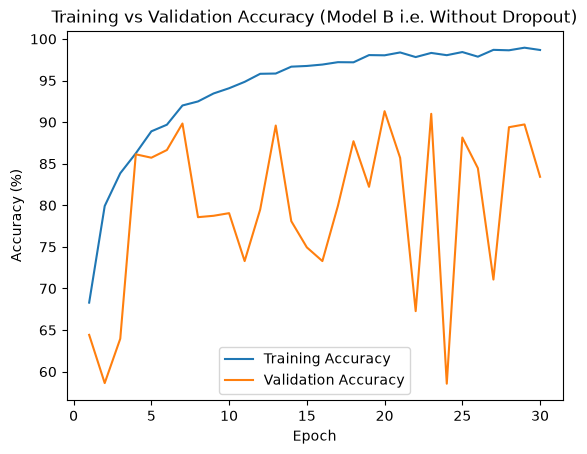

In [122]:
# Without Dropout (Model B)
epochs = list(range(1, 31))

train_accuracy = [
    68.3016,
    79.9153,
    83.8519,
    86.2487,
    88.8942,
    89.6878,
    92.0000,
    92.4868,
    93.4444,
    94.0741,
    94.8413,
    95.8095,
    95.8413,
    96.6667,
    96.7513,
    96.9206,
    97.2063,
    97.1905,
    98.0582,
    98.0317,
    98.3757,
    97.8201,
    98.3175,
    98.0476,
    98.4233,
    97.8677,
    98.6878,
    98.6349,
    98.9471,
    98.6720
]

val_accuracy = [
    64.4259,
    58.6296,
    63.9630,
    86.1296,
    85.7222,
    86.6481,
    89.8333,
    78.5741,
    78.7407,
    79.0556,
    73.2963,
    79.5000,
    89.5926,
    78.0926,
    74.9444,
    73.2963,
    79.9444,
    87.7037,
    82.2222,
    91.3148,
    85.7037,
    67.2778,
    91.0000,
    58.5556,
    88.1481,
    84.4630,
    71.0741,
    89.3889,
    89.7222,
    83.4259
]

plt.plot(epochs, train_accuracy, label = "Training Accuracy")
plt.plot(epochs, val_accuracy, label = "Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (Model B i.e. Without Dropout)")
plt.legend()
plt.show()

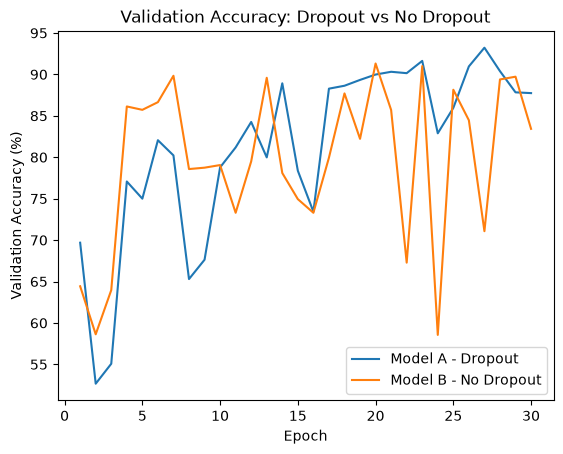

In [125]:
plt.plot(epochs_A, val_accuracy_A, label="Model A - Dropout")
plt.plot(epochs, val_accuracy, label="Model B - No Dropout")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy: Dropout vs No Dropout")
plt.legend()
plt.show()

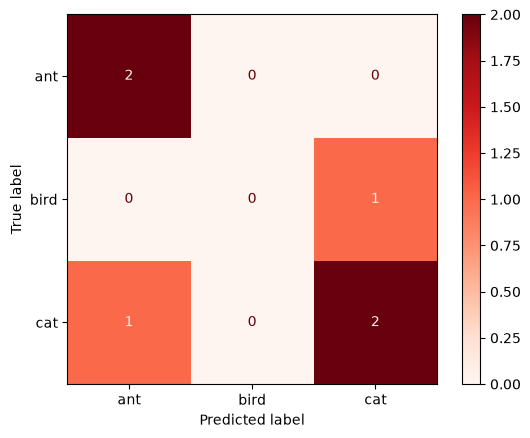

In [134]:
import sklearn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = ["cat", "ant", "cat", "cat", "ant", "bird"]
y_pred = ["ant", "ant", "cat", "cat", "ant", "cat"]
confusion_matrix(y_true, y_pred, labels=["ant", "bird", "cat"])

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap=plt.cm.Reds)

plt.show()